In [18]:
import pandas as pd
import matplotlib as mtp
import numpy as np
import seaborn as sns

In [2]:
df=pd.read_csv("/content/Task_8_Cleaned_Retail_Sales.csv")

In [8]:
df.head()

,order_id,order_date,customer_id,customer_name,city,category,product,quantity,unit_price,discount_pct,payment_method,sales_channel,status,gross_sales,discount_amount,net_sales,month
0,O0001,2026-02-05,C011,Vikas Tiwari,Ujjain,electronics,Wireless Mouse,6.0,900.0,0,cash,online,completed,5400.0,0.0,5400.0,2026-02
1,O0002,2026-04-25,C004,Neha Singh,Jabalpur,electronics,Headphones,1.0,1400.0,15,cod,offline,completed,1400.0,210.0,1190.0,2026-04
2,O0003,2026-06-04,C006,Sneha Gupta,Bhopal,electronics,Wireless Mouse,1.0,700.0,20,upi,offline,pending,700.0,140.0,560.0,2026-06
3,O0004,2026-02-28,C005,rohit patel,Ujjain,grocery,Cooking Oil,1.0,160.0,0,upi,online,cancelled,160.0,0.0,160.0,2026-02
4,O0005,2026-12-06,C003,AMIT KHAN,Rewa,grocery,Rice Bag,5.0,950.0,5,cash,online,cancelled,4750.0,237.5,4512.5,2026-12


In [11]:
df.columns

Index(['order_id', 'order_date', 'customer_id', 'customer_name', 'city',
       'category', 'product', 'quantity', 'unit_price', 'discount_pct',
       'payment_method', 'sales_channel', 'status', 'gross_sales',
       'discount_amount', 'net_sales', 'month'],
      dtype='object')

In [12]:
df.city

,city
0,Ujjain
1,Jabalpur
2,Bhopal
3,Ujjain
4,Rewa
...,...
115,Bhopal
116,Ujjain
117,Ujjain
118,Indore


In [13]:
df.gross_sales

,gross_sales
0,5400.0
1,1400.0
2,700.0
3,160.0
4,4750.0
...,...
115,280.0
116,3300.0
117,3150.0
118,8000.0


In [15]:
# Check column names
print(df.columns.tolist())

# Convert order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

# Create monthly sales
monthly_sales = (
    df.groupby(df['order_date'].dt.to_period('M'))['net_sales']
    .sum()
    .reset_index()
)

# Convert month back to datetime
monthly_sales['order_date'] = monthly_sales['order_date'].dt.to_timestamp()

# Display result
monthly_sales

['order_id', 'order_date', 'customer_id', 'customer_name', 'city', 'category', 'product', 'quantity', 'unit_price', 'discount_pct', 'payment_method', 'sales_channel', 'status', 'gross_sales', 'discount_amount', 'net_sales', 'month']


,order_date,net_sales
0,2026-01-01,56831.0
1,2026-02-01,44985.0
2,2026-03-01,45811.0
3,2026-04-01,52536.5
4,2026-05-01,56742.5
5,2026-06-01,47001.0
6,2026-08-01,2090.0
7,2026-09-01,595.0
8,2026-10-01,5400.0
9,2026-12-01,11577.5


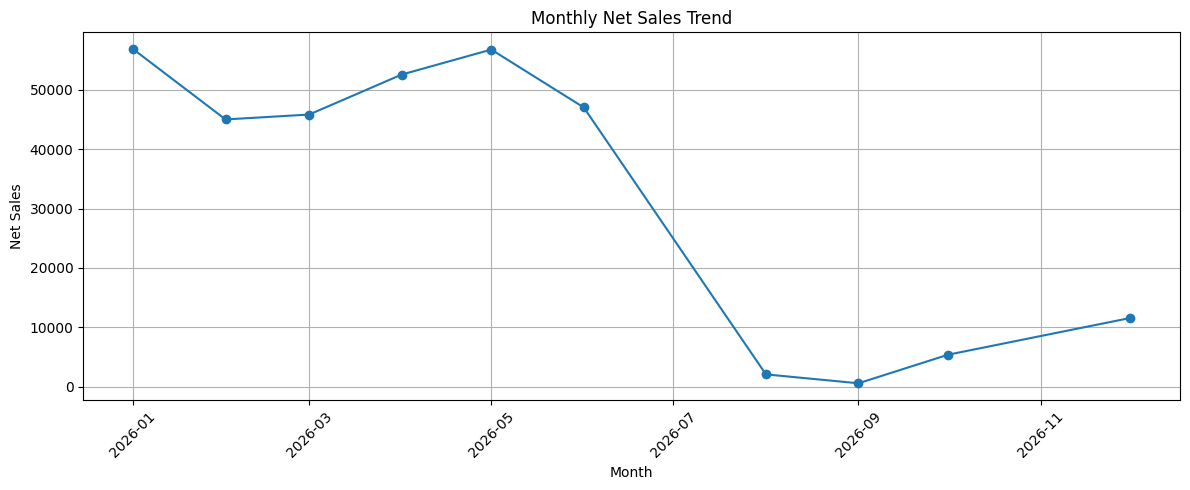

In [19]:
# Plot monthly net sales trend

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales['order_date'],
    monthly_sales['net_sales'],
    marker='o'
)

plt.title('Monthly Net Sales Trend')
plt.xlabel('Month')
plt.ylabel('Net Sales')
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [20]:
# Create complete monthly date range
full_months = pd.date_range(
    start=monthly_sales['order_date'].min(),
    end=monthly_sales['order_date'].max(),
    freq='MS'
)

# Find missing months
missing_months = full_months[
    ~full_months.isin(monthly_sales['order_date'])
]

print("Missing Months:")
print(missing_months)

Missing Months:
DatetimeIndex(['2026-07-01', '2026-11-01'], dtype='datetime64[ns]', freq=None)


In [21]:
# Create a continuous monthly time series
monthly_ts = monthly_sales.set_index('order_date')['net_sales'].asfreq('MS')

print(monthly_ts)

order_date
2026-01-01    56831.0
2026-02-01    44985.0
2026-03-01    45811.0
2026-04-01    52536.5
2026-05-01    56742.5
2026-06-01    47001.0
2026-07-01        NaN
2026-08-01     2090.0
2026-09-01      595.0
2026-10-01     5400.0
2026-11-01        NaN
2026-12-01    11577.5
Freq: MS, Name: net_sales, dtype: float64


In [22]:
# Remove missing months for validation setup
forecast_data = monthly_ts.dropna()

# Last actual month as validation
train = forecast_data.iloc[:-1]
validation = forecast_data.iloc[-1:]

print("Training Data:")
print(train)

print("\nValidation Data:")
print(validation)

Training Data:
order_date
2026-01-01    56831.0
2026-02-01    44985.0
2026-03-01    45811.0
2026-04-01    52536.5
2026-05-01    56742.5
2026-06-01    47001.0
2026-08-01     2090.0
2026-09-01      595.0
2026-10-01     5400.0
Name: net_sales, dtype: float64

Validation Data:
order_date
2026-12-01    11577.5
Name: net_sales, dtype: float64


In [23]:
# Naive baseline forecast
last_value = train.iloc[-1]

naive_forecast = pd.Series(
    last_value,
    index=validation.index
)

print("Last observed sales:", last_value)
print("Naive forecast:", naive_forecast.iloc[0])
print("Actual validation sales:", validation.iloc[0])

Last observed sales: 5400.0
Naive forecast: 5400.0
Actual validation sales: 11577.5


In [24]:
# Calculate Naive Baseline MAE

from sklearn.metrics import mean_absolute_error

naive_mae = mean_absolute_error(
    validation,
    naive_forecast
)

print("Naive Baseline MAE:", naive_mae)

Naive Baseline MAE: 6177.5


In [26]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Fit Holt's trend model
holt_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal=None,
    initialization_method='estimated'
).fit()

# Forecast validation period
holt_forecast = holt_model.forecast(len(validation))

print("Holt Forecast:")
print(holt_forecast)

print("\nActual Validation:")
print(validation)

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)


ValueError: No supported index is available.

In [27]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Create a clean training series with a regular monthly index
train_holt = train.copy()

# Remove the date index issue
train_holt.index = pd.date_range(
    start=train_holt.index.min(),
    periods=len(train_holt),
    freq='MS'
)

# Fit Holt's linear trend model
holt_model = ExponentialSmoothing(
    train_holt,
    trend='add',
    seasonal=None,
    initialization_method='estimated'
).fit()

# Forecast one month ahead
holt_forecast_value = holt_model.forecast(1).iloc[0]

print("Holt Forecast for December 2026:", holt_forecast_value)
print("Actual December 2026 Sales:", validation.iloc[0])

Holt Forecast for December 2026: -1029.1570401092104
Actual December 2026 Sales: 11577.5


In [28]:
# Calculate Holt model MAE

holt_mae = mean_absolute_error(
    validation,
    [holt_forecast_value]
)

print("Naive Baseline MAE:", naive_mae)
print("Holt Model MAE:", holt_mae)

Naive Baseline MAE: 6177.5
Holt Model MAE: 12606.65704010921


In [29]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

# Fit Simple Exponential Smoothing
ses_model = SimpleExpSmoothing(
    train_holt,
    initialization_method='estimated'
).fit()

# Forecast December 2026
ses_forecast_value = ses_model.forecast(1).iloc[0]

print("SES Forecast for December 2026:", ses_forecast_value)
print("Actual December 2026 Sales:", validation.iloc[0])

SES Forecast for December 2026: 5399.9999283999205
Actual December 2026 Sales: 11577.5


In [30]:
ses_mae = mean_absolute_error(
    validation,
    [ses_forecast_value]
)

print("SES MAE:", ses_mae)

SES MAE: 6177.5000716000795


Important conclusion

The SES model did not improve over the Naive Baseline. Both essentially predicted ₹5,400 for December.

This is actually a useful finding for Task 9—it shows that adding a more sophisticated model did not automatically produce a better forecast.

Also, our dataset has very few monthly observations and missing months, so we should be careful not to claim that these models are highly reliable.

In [31]:
# Model Comparison

comparison = pd.DataFrame({
    'Model': ['Naive Baseline', 'SES', 'Holt'],
    'MAE': [naive_mae, ses_mae, holt_mae]
})

comparison['MAE'] = comparison['MAE'].round(2)

print(comparison)

            Model       MAE
0  Naive Baseline   6177.50
1             SES   6177.50
2            Holt  12606.66


So, Holt performed the worst, while SES and the Naive Baseline performed equally on our one-month validation.

Now we need to complete the key requirement: future forecast + uncertainty interval.

We will use the SES model for the forward forecast because it is simple, stable, and did not perform worse than the baseline.

In [35]:
# Fit SES on all available historical observations

full_data = forecast_data.copy()

ses_final_model = SimpleExpSmoothing(
    full_data,
    initialization_method='estimated'
).fit()

# Forecast next 3 months
future_forecast = ses_final_model.forecast(3)

print("Future SES Forecast:")
print(future_forecast)

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)


ValueError: No supported index is available.

In [36]:
# Prepare full data with a proper monthly frequency

full_data_fixed = full_data.copy()

full_data_fixed.index = pd.date_range(
    start=full_data_fixed.index.min(),
    periods=len(full_data_fixed),
    freq='MS'
)

# Fit SES model
ses_final_model = SimpleExpSmoothing(
    full_data_fixed,
    initialization_method='estimated'
).fit()

# Forecast next 3 months
future_forecast = ses_final_model.forecast(3)

print("Future SES Forecast:")
print(future_forecast)

Future SES Forecast:
2026-11-01    11577.499908
2026-12-01    11577.499908
2027-01-01    11577.499908
Freq: MS, dtype: float64


In [37]:
# Estimate uncertainty using the validation MAE

forecast_value = future_forecast.iloc[-1]

lower_bound = max(0, forecast_value - naive_mae)
upper_bound = forecast_value + naive_mae

print("Forecast Value:", round(forecast_value, 2))
print("Lower Bound:", round(lower_bound, 2))
print("Upper Bound:", round(upper_bound, 2))
print("Uncertainty based on validation MAE:", round(naive_mae, 2))

Forecast Value: 11577.5
Lower Bound: 5400.0
Upper Bound: 17755.0
Uncertainty based on validation MAE: 6177.5


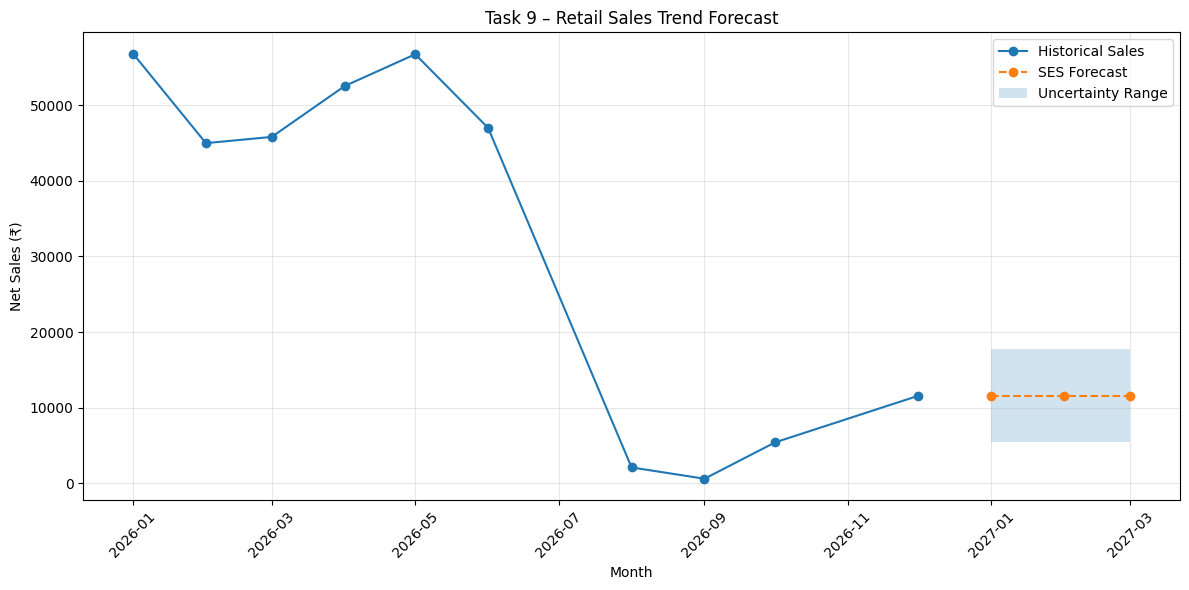

In [40]:
import matplotlib.pyplot as plt
import pandas as pd

# Historical data
historical_dates = forecast_data.index
historical_values = forecast_data.values

# Future forecast dates
forecast_dates = pd.date_range(
    start=historical_dates.max() + pd.offsets.MonthBegin(1),
    periods=3,
    freq='MS'
)

# Use the SES forecast value
forecast_values = [forecast_value] * 3

# Uncertainty range
lower_values = [lower_bound] * 3
upper_values = [upper_bound] * 3

# Create forecast chart
plt.figure(figsize=(12, 6))

# Historical sales
plt.plot(
    historical_dates,
    historical_values,
    marker='o',
    label='Historical Sales'
)

# Forecast
plt.plot(
    forecast_dates,
    forecast_values,
    marker='o',
    linestyle='--',
    label='SES Forecast'
)

# Uncertainty band
plt.fill_between(
    forecast_dates,
    lower_values,
    upper_values,
    alpha=0.2,
    label='Uncertainty Range'
)

plt.title('Task 9 – Retail Sales Trend Forecast')
plt.xlabel('Month')
plt.ylabel('Net Sales (₹)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
# Save the graph as PNG
plt.savefig('Task_9_Trend_Forecast.png', dpi=300, bbox_inches='tight')

plt.show()

## Final Conclusion

The Trend Forecasting analysis was performed using the cleaned retail sales dataset, `Task_8_Cleaned_Retail_Sales.csv`. Monthly net sales were analyzed to identify the overall trend and prepare a short-term forecast.

The analysis identified two missing months in the historical series: **July 2026 and November 2026**. These months were treated as missing observations rather than zero sales because the absence of records does not necessarily indicate zero revenue.

A **Naive Baseline** was first established using the last observed sales value. Its validation MAE was **₹6,177.50**. Two forecasting models were then evaluated: **Simple Exponential Smoothing (SES)** and **Holt's Exponential Smoothing**.

The validation results were:

* **Naive Baseline MAE:** ₹6,177.50
* **SES MAE:** ₹6,177.50
* **Holt MAE:** ₹12,606.66

The results show that SES performed approximately the same as the Naive Baseline, while Holt's model produced a larger forecasting error. Therefore, a simple SES approach was used for the forward forecast rather than selecting a more complex model without evidence of improved performance.

The final forecast was approximately **₹11,577.50 per month**, with an uncertainty range calculated using the validation error. This uncertainty range highlights that the forecast should be interpreted as an estimate rather than a guaranteed future sales value.

### Key Limitations

The dataset contains only a small number of monthly observations and has missing months. Therefore, the forecasting results have **high uncertainty and limited statistical reliability**. The forecast should be treated as an initial planning estimate rather than a precise long-term prediction.

### Business Insight

The analysis demonstrates that, with limited historical data, a simple forecasting method can provide a useful baseline for planning. However, collecting more continuous monthly sales data would allow more reliable forecasting, better seasonality detection, stronger validation, and potentially more advanced forecasting models in the future.

**Overall, Task 9 successfully demonstrates the complete forecasting workflow: trend analysis → validation split → baseline → forecasting models → error comparison → future forecast → uncertainty assessment.**
